# Ecommerce Checkout Funnel & Purchase Intent Analysis

This project analyzes how pre-purchase browsing and cart behavior relates to ecommerce conversion.

The goal is not simply to predict whether a session purchases. The analysis also tests how much additional predictive information appears once a shopper reaches the cart stage of the funnel.

To avoid target leakage, all model features are created only from activity that occurs before the first purchase event. I then compare:

- a full model using pre-purchase view and cart behavior, and
- a browsing-only model using view behavior alone.

This comparison helps quantify how strongly late-funnel cart activity separates high-intent sessions from browsing-only sessions.


### Data Inspection

I first inspected the raw ecommerce event data to understand its structure, data quality, and level of granularity.

The source data is **event level**, meaning a single shopping session can contain multiple rows for views, cart actions, and purchases. Because the modeling target is whether an entire session eventually results in a purchase, the raw data cannot be used directly as one row per prediction. It must first be transformed into a **session-level feature table**.

I also reviewed summary statistics, missing values, and data types. In particular, `event_time` needs to be converted to a datetime field before creating time-based features such as session duration, hour of day, and day of week.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
events = pd.read_csv("events.csv")
events.head()


,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2020-09-24 11:57:06 UTC,view,1996170,2144415922528452715,electronics.telephone,NaN,31.90,1.515916e+18,LJuJVLEjPT
1,2020-09-24 11:57:26 UTC,view,139905,2144415926932472027,computers.components.cooler,zalman,17.16,1.515916e+18,tdicluNnRY
2,2020-09-24 11:57:27 UTC,view,215454,2144415927158964449,NaN,NaN,9.81,1.515916e+18,4TMArHtXQy
3,2020-09-24 11:57:33 UTC,view,635807,2144415923107266682,computers.peripherals.printer,pantum,113.81,1.515916e+18,aGFYrNgC08
4,2020-09-24 11:57:36 UTC,view,3658723,2144415921169498184,NaN,cameronsino,15.87,1.515916e+18,aa4mmk0kwQ


In [ ]:
events.head()

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2020-09-24 11:57:06 UTC,view,1996170,2144415922528452715,electronics.telephone,NaN,31.90,1.515916e+18,LJuJVLEjPT
1,2020-09-24 11:57:26 UTC,view,139905,2144415926932472027,computers.components.cooler,zalman,17.16,1.515916e+18,tdicluNnRY
2,2020-09-24 11:57:27 UTC,view,215454,2144415927158964449,NaN,NaN,9.81,1.515916e+18,4TMArHtXQy
3,2020-09-24 11:57:33 UTC,view,635807,2144415923107266682,computers.peripherals.printer,pantum,113.81,1.515916e+18,aGFYrNgC08
4,2020-09-24 11:57:36 UTC,view,3658723,2144415921169498184,NaN,cameronsino,15.87,1.515916e+18,aa4mmk0kwQ


In [ ]:
events.describe()

,product_id,category_id,price,user_id
count,1.686130e+05,1.686130e+05,168613.000000,1.686120e+05
mean,1.734480e+06,2.144424e+18,113.760481,1.515916e+18
std,1.397029e+06,6.542217e+14,325.284432,2.730525e+07
min,1.050000e+02,2.144416e+18,0.370000,1.515916e+18
25%,6.367250e+05,2.144416e+18,21.900000,1.515916e+18
50%,1.282333e+06,2.144416e+18,52.050000,1.515916e+18
75%,3.563975e+06,2.144416e+18,126.680000,1.515916e+18
max,4.183880e+06,2.227847e+18,64771.060000,1.515916e+18


In [ ]:
events.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 168613 entries, 0 to 168612
Data columns (total 9 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   event_time     168613 non-null  object 
 1   event_type     168613 non-null  object 
 2   product_id     168613 non-null  int64  
 3   category_id    168613 non-null  int64  
 4   category_code  118815 non-null  object 
 5   brand          124679 non-null  object 
 6   price          168613 non-null  float64
 7   user_id        168612 non-null  float64
 8   user_session   168580 non-null  object 
dtypes: float64(2), int64(2), object(5)
memory usage: 11.6+ MB


In [ ]:
events.isnull().sum()

,0
event_time,0
event_type,0
product_id,0
category_id,0
category_code,49798
brand,43934
price,0
user_id,1
user_session,33


In [ ]:
pd.Series({
    "users": events["user_id"].nunique(),
    "sessions": events["user_session"].nunique(),
    "products": events["product_id"].nunique(),
    "category_ids": events["category_id"].nunique(),
    "category_codes": events["category_code"].nunique(),
    "brands": events["brand"].nunique(),})

,0
users,44258
sessions,100015
products,29075
category_ids,655
category_codes,106
brands,885


### Data Cleaning

I cleaned the event data before constructing session-level features.

Exact duplicate rows were removed to avoid double-counting user behavior. I then removed records missing fields required for modeling, including `event_time`, `event_type`, `product_id`, `price`, `user_id`, and `user_session`.

`event_time` was converted to a datetime field so that session timing features could be calculated later. Invalid price records were also removed by keeping only rows with non-negative prices.

After cleaning, I calculated the raw session purchase rate as a baseline before feature engineering.


In [ ]:
clean_events = events.copy()

# Drop exact duplicate rows
before = len(clean_events)
clean_events = clean_events.drop_duplicates()
print(f"Dropped {before - len(clean_events):,} duplicate rows")

# Drop rows missing fields required for session-level modeling
critical_cols = ["event_time", "event_type", "product_id", "price", "user_id", "user_session"]
clean_events = clean_events.dropna(subset=critical_cols)

# Convert timestamp
clean_events["event_time"] = pd.to_datetime(clean_events["event_time"], errors="coerce")
clean_events = clean_events.dropna(subset=["event_time"])

# Remove invalid prices if any exist
clean_events = clean_events[clean_events["price"] >= 0]

print("Cleaned shape:", clean_events.shape)
clean_events.head()

Dropped 131 duplicate rows
Cleaned shape: (168449, 9)


,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2020-09-24 11:57:06+00:00,view,1996170,2144415922528452715,electronics.telephone,NaN,31.90,1.515916e+18,LJuJVLEjPT
1,2020-09-24 11:57:26+00:00,view,139905,2144415926932472027,computers.components.cooler,zalman,17.16,1.515916e+18,tdicluNnRY
2,2020-09-24 11:57:27+00:00,view,215454,2144415927158964449,NaN,NaN,9.81,1.515916e+18,4TMArHtXQy
3,2020-09-24 11:57:33+00:00,view,635807,2144415923107266682,computers.peripherals.printer,pantum,113.81,1.515916e+18,aGFYrNgC08
4,2020-09-24 11:57:36+00:00,view,3658723,2144415921169498184,NaN,cameronsino,15.87,1.515916e+18,aa4mmk0kwQ


In [ ]:
clean_events["event_type"].value_counts()

,count
event_type,
view,152917
cart,9017
purchase,6515


In [ ]:
session_purchase_rate = (
    clean_events.groupby("user_session")["event_type"]
    .apply(lambda x: (x == "purchase").any())
    .mean())

session_purchase_rate

np.float64(0.042843573463980406)

### Session-Level Feature Engineering

I converted the event-level data into a session-level modeling table with one row per `user_session`.

The target variable, `purchased`, equals 1 if a session eventually contains a purchase event and 0 otherwise.

To reduce **target leakage**, model features are created only from activity that occurred before the first purchase:

- For purchasing sessions, only view and cart activity **before the first purchase event** is retained.
- For non-purchasing sessions, all available view and cart activity is retained.
- Purchase events themselves are never used as predictors.

The engineered features capture engagement, product exploration, cart behavior, pricing, and session timing. Examples include total events, views, carts, unique products, unique categories, average price, session duration, cart rate, and cart-to-view ratio.

The raw cleaned data has a purchase rate of about **4.28%**, while the final feature table has a purchase rate of about **3.87%**. This changes because the feature table only contains sessions with usable pre-purchase view or cart activity. Sessions that cannot produce those predictors are excluded during aggregation.


In [ ]:
# First purchase time per session
first_purchase_time = (
    clean_events[clean_events["event_type"] == "purchase"]
    .groupby("user_session")["event_time"]
    .min()
    .reset_index()
    .rename(columns={"event_time": "first_purchase_time"}))

first_purchase_time.head()

,user_session,first_purchase_time
0,01471d2f-3aae-432e-8c5c-4b3ab24723c8,2020-09-24 12:48:35+00:00
1,01U5LKybhU,2020-10-25 09:03:06+00:00
2,02N2rUZOAe,2020-10-10 12:59:57+00:00
3,02amSlCIGB,2020-10-01 08:22:35+00:00
4,02cmqEzaTl,2020-10-01 14:26:17+00:00


In [ ]:
# Add first purchase time to every event
model_events = clean_events.merge(
    first_purchase_time,
    on="user_session",
    how="left")

model_events.head()

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session,first_purchase_time
0,2020-09-24 11:57:06+00:00,view,1996170,2144415922528452715,electronics.telephone,NaN,31.90,1.515916e+18,LJuJVLEjPT,NaT
1,2020-09-24 11:57:26+00:00,view,139905,2144415926932472027,computers.components.cooler,zalman,17.16,1.515916e+18,tdicluNnRY,NaT
2,2020-09-24 11:57:27+00:00,view,215454,2144415927158964449,NaN,NaN,9.81,1.515916e+18,4TMArHtXQy,NaT
3,2020-09-24 11:57:33+00:00,view,635807,2144415923107266682,computers.peripherals.printer,pantum,113.81,1.515916e+18,aGFYrNgC08,NaT
4,2020-09-24 11:57:36+00:00,view,3658723,2144415921169498184,NaN,cameronsino,15.87,1.515916e+18,aa4mmk0kwQ,NaT


In [ ]:
# Keep only behavior before the first purchase.
# If a session never purchased, keep all events.
feature_events = model_events[
    (model_events["first_purchase_time"].isna()) |
    (model_events["event_time"] < model_events["first_purchase_time"])].copy()

# The model should only see pre purchase browsing/cart behavior.
feature_events = feature_events[feature_events["event_type"].isin(["view", "cart"])]

feature_events["event_type"].value_counts()

,count
event_type,
view,149117
cart,8490


In [ ]:
# Target from cleaned data
session_target = (
    clean_events.groupby("user_session")["event_type"]
    .apply(lambda x: (x == "purchase").any())
    .astype(int)
    .reset_index()
    .rename(columns={"event_type": "purchased"}))

session_target["purchased"].value_counts(normalize=True).round(4) * 100

,proportion
purchased,
0,95.72
1,4.28


In [ ]:
# Build one row per session from pre-purchase feature events
session_features = feature_events.groupby("user_session").agg(
    user_id=("user_id", "first"),
    session_start=("event_time", "min"),
    session_end=("event_time", "max"),
    total_events=("event_type", "count"),
    unique_products=("product_id", "nunique"),
    unique_categories=("category_code", "nunique"),
    avg_price=("price", "mean"),
    max_price=("price", "max"),
    min_price=("price", "min")).reset_index()

session_features.head()

,user_session,user_id,session_start,session_end,total_events,unique_products,unique_categories,avg_price,max_price,min_price
0,000c34fa-991f-442a-8e07-8c472269bec6,1.515916e+18,2020-09-30 17:52:02+00:00,2020-09-30 17:52:02+00:00,1,1,1,421.22,421.22,421.22
1,002DmERG1w,1.515916e+18,2020-09-26 18:59:06+00:00,2020-09-26 18:59:06+00:00,1,1,1,27.95,27.95,27.95
2,003QqC0jk0,1.515916e+18,2020-10-25 15:23:25+00:00,2020-10-25 15:23:25+00:00,1,1,0,62.22,62.22,62.22
3,0041IWrUEl,1.515916e+18,2020-10-28 07:13:45+00:00,2020-10-28 07:13:45+00:00,1,1,1,324.16,324.16,324.16
4,009so5Mgnj,1.515916e+18,2020-09-26 16:55:42+00:00,2020-09-26 16:55:42+00:00,1,1,1,41.90,41.90,41.90


In [ ]:
# Add view/cart counts
view_cart_counts = (
    feature_events
    .pivot_table(
        index="user_session",
        columns="event_type",
        values="product_id",
        aggfunc="count",
        fill_value=0)
    .reset_index())

session_features = session_features.merge(
    view_cart_counts,
    on="user_session",
    how="left")

for col in ["view", "cart"]:
    if col not in session_features.columns:
        session_features[col] = 0

session_features.head()

,user_session,user_id,session_start,session_end,total_events,unique_products,unique_categories,avg_price,max_price,min_price,cart,view
0,000c34fa-991f-442a-8e07-8c472269bec6,1.515916e+18,2020-09-30 17:52:02+00:00,2020-09-30 17:52:02+00:00,1,1,1,421.22,421.22,421.22,0,1
1,002DmERG1w,1.515916e+18,2020-09-26 18:59:06+00:00,2020-09-26 18:59:06+00:00,1,1,1,27.95,27.95,27.95,0,1
2,003QqC0jk0,1.515916e+18,2020-10-25 15:23:25+00:00,2020-10-25 15:23:25+00:00,1,1,0,62.22,62.22,62.22,0,1
3,0041IWrUEl,1.515916e+18,2020-10-28 07:13:45+00:00,2020-10-28 07:13:45+00:00,1,1,1,324.16,324.16,324.16,0,1
4,009so5Mgnj,1.515916e+18,2020-09-26 16:55:42+00:00,2020-09-26 16:55:42+00:00,1,1,1,41.90,41.90,41.90,0,1


In [ ]:
# Merge the target onto the feature table
session_features = session_features.merge(
    session_target,
    on="user_session",
    how="left")

session_features["purchased"].value_counts(normalize=True).round(4) * 100

,proportion
purchased,
0,96.13
1,3.87


In [ ]:
# Add simple behavioral/time features
session_features["session_duration_seconds"] = (
    session_features["session_end"] - session_features["session_start"]
).dt.total_seconds()

session_features["cart_rate"] = session_features["cart"] / session_features["total_events"]
session_features["view_rate"] = session_features["view"] / session_features["total_events"]
session_features["cart_to_view_ratio"] = session_features["cart"] / session_features["view"].replace(0, 1)

session_features["session_hour"] = session_features["session_start"].dt.hour
session_features["session_dayofweek"] = session_features["session_start"].dt.dayofweek
session_features["is_weekend"] = session_features["session_dayofweek"].isin([5, 6]).astype(int)

session_features.head()

,user_session,user_id,session_start,session_end,total_events,unique_products,unique_categories,avg_price,max_price,min_price,cart,view,purchased,session_duration_seconds,cart_rate,view_rate,cart_to_view_ratio,session_hour,session_dayofweek,is_weekend
0,000c34fa-991f-442a-8e07-8c472269bec6,1.515916e+18,2020-09-30 17:52:02+00:00,2020-09-30 17:52:02+00:00,1,1,1,421.22,421.22,421.22,0,1,0,0.0,0.0,1.0,0.0,17,2,0
1,002DmERG1w,1.515916e+18,2020-09-26 18:59:06+00:00,2020-09-26 18:59:06+00:00,1,1,1,27.95,27.95,27.95,0,1,0,0.0,0.0,1.0,0.0,18,5,1
2,003QqC0jk0,1.515916e+18,2020-10-25 15:23:25+00:00,2020-10-25 15:23:25+00:00,1,1,0,62.22,62.22,62.22,0,1,0,0.0,0.0,1.0,0.0,15,6,1
3,0041IWrUEl,1.515916e+18,2020-10-28 07:13:45+00:00,2020-10-28 07:13:45+00:00,1,1,1,324.16,324.16,324.16,0,1,0,0.0,0.0,1.0,0.0,7,2,0
4,009so5Mgnj,1.515916e+18,2020-09-26 16:55:42+00:00,2020-09-26 16:55:42+00:00,1,1,1,41.90,41.90,41.90,0,1,0,0.0,0.0,1.0,0.0,16,5,1


### Exploratory Analysis of the Modeling Table

Before modeling, I reviewed the final session-level table to confirm that the engineered features were usable and to compare behavior between purchasing and non-purchasing sessions.

Purchasing sessions showed substantially stronger pre-purchase engagement:

- more total events,
- more views,
- much more cart activity,
- more unique products,
- longer session durations,
- higher cart rates, and
- higher cart-to-view ratios.

The largest separation appears in the **cart-related variables**. Purchasing sessions averaged about **1.14 cart events** compared with **0.04** for non-purchasing sessions, and their average cart-to-view ratio was approximately **0.73** versus **0.02**.

In [ ]:
session_features.info()
session_features.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99579 entries, 0 to 99578
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype              
---  ------                    --------------  -----              
 0   user_session              99579 non-null  object             
 1   user_id                   99579 non-null  float64            
 2   session_start             99579 non-null  datetime64[ns, UTC]
 3   session_end               99579 non-null  datetime64[ns, UTC]
 4   total_events              99579 non-null  int64              
 5   unique_products           99579 non-null  int64              
 6   unique_categories         99579 non-null  int64              
 7   avg_price                 99579 non-null  float64            
 8   max_price                 99579 non-null  float64            
 9   min_price                 99579 non-null  float64            
 10  cart                      99579 non-null  int64              
 11  view           

,0
user_session,0
user_id,0
session_start,0
session_end,0
total_events,0
unique_products,0
unique_categories,0
avg_price,0
max_price,0
min_price,0


In [ ]:
session_features.groupby("purchased")[[
    "total_events",
    "view",
    "cart",
    "unique_products",
    "unique_categories",
    "avg_price",
    "session_duration_seconds",
    "cart_rate",
    "cart_to_view_ratio"
]].mean().T

purchased,0,1
total_events,1.508252,3.435178
view,1.465246,2.299039
cart,0.043006,1.136139
unique_products,1.225655,1.564562
unique_categories,0.693920,0.830605
avg_price,113.971709,88.594113
session_duration_seconds,9737.063522,14952.278514
cart_rate,0.012968,0.391964
cart_to_view_ratio,0.022764,0.725798


### Purchase Intent Modeling

I used logistic regression to model whether a session eventually resulted in a purchase.

Logistic regression is appropriate here because the target is binary, it produces estimated purchase probabilities, and it provides an interpretable baseline for comparing different feature sets.

Purchasing sessions represent only a small share of the data, so overall accuracy would be misleading by itself. I therefore used `class_weight="balanced"` and evaluated performance using:

- precision,
- recall,
- F1-score,
- ROC-AUC, and
- the confusion matrix.

The first model uses the complete set of pre-purchase browsing and cart features.


In [ ]:
feature_cols = [
    "total_events",
    "view",
    "cart",
    "unique_products",
    "unique_categories",
    "avg_price",
    "max_price",
    "min_price",
    "session_duration_seconds",
    "cart_rate",
    "view_rate",
    "cart_to_view_ratio",
    "session_hour",
    "session_dayofweek",
    "is_weekend"]

X = session_features[feature_cols].fillna(0)
y = session_features["purchased"]

X.head()

,total_events,view,cart,unique_products,unique_categories,avg_price,max_price,min_price,session_duration_seconds,cart_rate,view_rate,cart_to_view_ratio,session_hour,session_dayofweek,is_weekend
0,1,1,0,1,1,421.22,421.22,421.22,0.0,0.0,1.0,0.0,17,2,0
1,1,1,0,1,1,27.95,27.95,27.95,0.0,0.0,1.0,0.0,18,5,1
2,1,1,0,1,0,62.22,62.22,62.22,0.0,0.0,1.0,0.0,15,6,1
3,1,1,0,1,1,324.16,324.16,324.16,0.0,0.0,1.0,0.0,7,2,0
4,1,1,0,1,1,41.90,41.90,41.90,0.0,0.0,1.0,0.0,16,5,1


In [ ]:
y.value_counts(normalize=True).round(4) * 100

,proportion
purchased,
0,96.13
1,3.87


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

log_model = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=42))])

log_model.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=42))])

In [ ]:
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

y_pred = log_model.predict(X_test)
y_proba = log_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.96      0.98     19146
           1       0.52      0.94      0.67       770

    accuracy                           0.96     19916
   macro avg       0.76      0.95      0.82     19916
weighted avg       0.98      0.96      0.97     19916

ROC-AUC: 0.9613842571301049
[[18472   674]
 [   45   725]]


### Full-Model Results and Business Interpretation

The full pre-purchase model achieved a **ROC-AUC of 0.961**, indicating strong separation between purchasing and non-purchasing sessions.

On the held-out test set, the confusion matrix was:

- **18,472 true negatives**
- **674 false positives**
- **45 false negatives**
- **725 true positives**

The model captured approximately **94% of actual purchasing sessions** (recall = 0.94), although precision for the purchase class was about **0.52**. In other words, the balanced model intentionally accepts more false positives in exchange for identifying most eventual purchasers.

That tradeoff can be reasonable for relatively low-cost interventions such as remarketing, cart reminders, or personalized onsite messaging, but it would be less appropriate for expensive actions where false positives carry a large cost.

Cart activity is also strongly associated with conversion before any model is applied. Sessions with no cart activity purchased only about **0.23%** of the time, while sessions containing at least one pre-purchase cart event converted at about **51.8%**. This makes cart behavior an important late-funnel signal, but it also raises a useful modeling question: **how much does cart-stage information improve prediction beyond browsing behavior alone?**


In [ ]:
session_features.groupby("purchased")[[
    "total_events",
    "view",
    "cart",
    "unique_products",
    "avg_price",
    "session_duration_seconds",
    "cart_rate",
    "cart_to_view_ratio"]].mean().T

purchased,0,1
total_events,1.508252,3.435178
view,1.465246,2.299039
cart,0.043006,1.136139
unique_products,1.225655,1.564562
avg_price,113.971709,88.594113
session_duration_seconds,9737.063522,14952.278514
cart_rate,0.012968,0.391964
cart_to_view_ratio,0.022764,0.725798


In [ ]:
pd.crosstab(
    session_features["cart"] > 0,
    session_features["purchased"],
    normalize="index")

purchased,0,1
cart,,
False,0.997720,0.002280
True,0.481914,0.518086


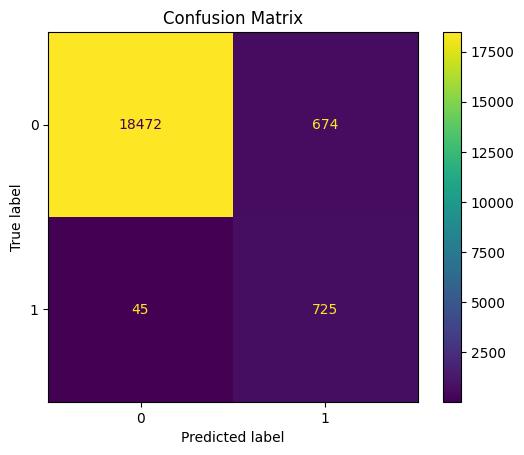

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

plt.title("Confusion Matrix")
plt.show()

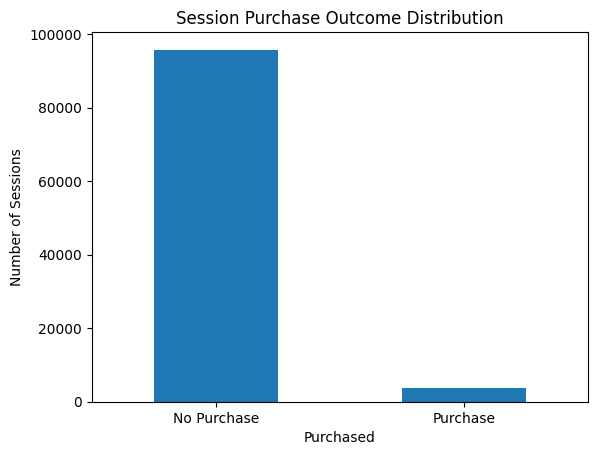

In [ ]:


session_features["purchased"].value_counts().sort_index().plot(kind="bar")

plt.title("Session Purchase Outcome Distribution")
plt.xlabel("Purchased")
plt.ylabel("Number of Sessions")
plt.xticks([0, 1], ["No Purchase", "Purchase"], rotation=0)
plt.show()

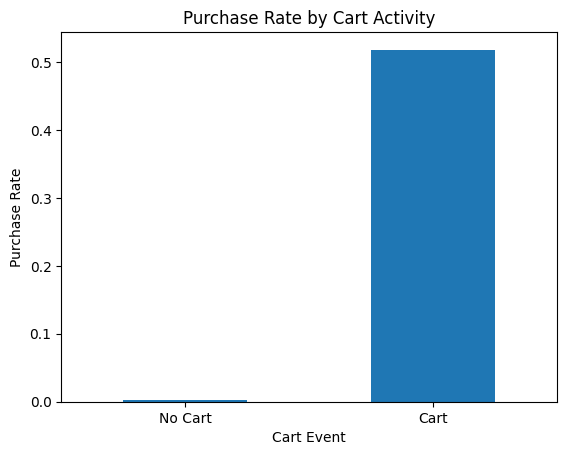

In [ ]:
cart_purchase_rate = (
    session_features
    .assign(has_cart=session_features["cart"] > 0)
    .groupby("has_cart")["purchased"]
    .mean())

cart_purchase_rate.plot(kind="bar")

plt.title("Purchase Rate by Cart Activity")
plt.xlabel("Cart Event")
plt.ylabel("Purchase Rate")
plt.xticks([0, 1], ["No Cart", "Cart"], rotation=0)
plt.show()

### Initial Findings

- **Purchase intent becomes much clearer deeper in the funnel.** Sessions with at least one pre-purchase cart event converted at about **51.8%**, compared with about **0.23%** for sessions without cart activity.

- **Purchasing sessions show stronger pre-purchase engagement.** They contain more total events, more views, more cart actions, more unique products, and longer session durations.

- **Cart intensity separates purchasers more strongly than raw activity volume.** Purchasing sessions have substantially higher cart rates and cart-to-view ratios.

- **The full model performs strongly as a late-stage purchase-intent model.** Its ROC-AUC is about **0.96**, with purchase recall around **0.94**.

These findings suggest that cart behavior is highly informative, but the full model alone cannot show how much of its performance comes specifically from late-funnel cart information. The next section addresses that question directly by comparing it with a browsing-only model.


## Full Model vs. Browsing-Only Model

The strongest analytical question in this project is whether **cart-stage behavior adds meaningful predictive information beyond browsing behavior alone**.

I compare two logistic regression models:

- **Full model:** uses pre-purchase view + cart session features.
- **Browsing-only model:** rebuilds the session table from **view events only**, removing direct cart-stage information.

Both models are evaluated on the **same eligible sessions** and use the same train/test split, scaling approach, logistic regression settings, and class weighting.

Rebuilding the browsing-only feature table is important. Simply deleting columns named `cart` would not create a clean comparison because other full-model features—such as total events, session duration, product counts, and price statistics—can also be influenced by cart events.

The comparison therefore measures how much predictive signal is gained when late-funnel cart behavior becomes available.


In [ ]:
# -----------------------------
# 1. Build the browsing-only feature table
# -----------------------------

view_only_events = feature_events[
    feature_events["event_type"] == "view"
].copy()

browse_features = (
    view_only_events.groupby("user_session").agg(
        browse_total_views=("event_type", "count"),
        browse_unique_products=("product_id", "nunique"),
        browse_unique_categories=("category_code", "nunique"),
        browse_avg_price=("price", "mean"),
        browse_max_price=("price", "max"),
        browse_min_price=("price", "min"),
        browse_session_start=("event_time", "min"),
        browse_session_end=("event_time", "max")
    )
    .reset_index()
)

browse_features["browse_session_duration_seconds"] = (
    browse_features["browse_session_end"] -
    browse_features["browse_session_start"]
).dt.total_seconds()

browse_features["browse_session_hour"] = (
    browse_features["browse_session_start"].dt.hour
)
browse_features["browse_session_dayofweek"] = (
    browse_features["browse_session_start"].dt.dayofweek
)
browse_features["browse_is_weekend"] = (
    browse_features["browse_session_dayofweek"].isin([5, 6]).astype(int)
)

browse_features = browse_features.merge(
    session_target,
    on="user_session",
    how="left"
)

browse_feature_cols = [
    "browse_total_views",
    "browse_unique_products",
    "browse_unique_categories",
    "browse_avg_price",
    "browse_max_price",
    "browse_min_price",
    "browse_session_duration_seconds",
    "browse_session_hour",
    "browse_session_dayofweek",
    "browse_is_weekend"
]

browse_features.head()


,user_session,browse_total_views,browse_unique_products,browse_unique_categories,browse_avg_price,browse_max_price,browse_min_price,browse_session_start,browse_session_end,browse_session_duration_seconds,browse_session_hour,browse_session_dayofweek,browse_is_weekend,purchased
0,000c34fa-991f-442a-8e07-8c472269bec6,1,1,1,421.22,421.22,421.22,2020-09-30 17:52:02+00:00,2020-09-30 17:52:02+00:00,0.0,17,2,0,0
1,002DmERG1w,1,1,1,27.95,27.95,27.95,2020-09-26 18:59:06+00:00,2020-09-26 18:59:06+00:00,0.0,18,5,1,0
2,003QqC0jk0,1,1,0,62.22,62.22,62.22,2020-10-25 15:23:25+00:00,2020-10-25 15:23:25+00:00,0.0,15,6,1,0
3,0041IWrUEl,1,1,1,324.16,324.16,324.16,2020-10-28 07:13:45+00:00,2020-10-28 07:13:45+00:00,0.0,7,2,0,0
4,009so5Mgnj,1,1,1,41.90,41.90,41.90,2020-09-26 16:55:42+00:00,2020-09-26 16:55:42+00:00,0.0,16,5,1,0


In [ ]:
# -----------------------------
# 2. Align both models to the exact same sessions
# -----------------------------

full_feature_cols = [
    "total_events",
    "view",
    "cart",
    "unique_products",
    "unique_categories",
    "avg_price",
    "max_price",
    "min_price",
    "session_duration_seconds",
    "cart_rate",
    "view_rate",
    "cart_to_view_ratio",
    "session_hour",
    "session_dayofweek",
    "is_weekend"
]

full_indexed = session_features.set_index("user_session")
browse_indexed = browse_features.set_index("user_session")

common_sessions = (
    full_indexed.index
    .intersection(browse_indexed.index)
    .sort_values()
)

X_full_compare = (
    full_indexed.loc[common_sessions, full_feature_cols]
    .fillna(0)
)

X_browse_compare = (
    browse_indexed.loc[common_sessions, browse_feature_cols]
    .fillna(0)
)

y_compare = (
    full_indexed.loc[common_sessions, "purchased"]
    .astype(int)
)

print(f"Sessions used in both models: {len(common_sessions):,}")
print("Purchase rate:", round(y_compare.mean(), 4))
print("Full-model features:", X_full_compare.shape[1])
print("Browsing-only features:", X_browse_compare.shape[1])


Sessions used in both models: 99,574
Purchase rate: 0.0386
Full-model features: 15
Browsing-only features: 10


In [ ]:
# -----------------------------
# 3. Use the same train/test sessions for both models
# -----------------------------

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

train_sessions, test_sessions = train_test_split(
    common_sessions,
    test_size=0.20,
    random_state=42,
    stratify=y_compare.loc[common_sessions]
)

def make_logistic_model():
    return Pipeline(steps=[
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            class_weight="balanced",
            max_iter=1000,
            random_state=42
        ))
    ])

full_compare_model = make_logistic_model()
browse_compare_model = make_logistic_model()

full_compare_model.fit(
    X_full_compare.loc[train_sessions],
    y_compare.loc[train_sessions]
)

browse_compare_model.fit(
    X_browse_compare.loc[train_sessions],
    y_compare.loc[train_sessions]
)

print("Both models trained on the same session split.")


Both models trained on the same session split.


In [ ]:
# -----------------------------
# 4. Compare performance
# -----------------------------

from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

y_test_compare = y_compare.loc[test_sessions]

def evaluate_model(model, X_test, y_test):
    pred = model.predict(X_test)
    proba = model.predict_proba(X_test)[:, 1]

    return {
        "ROC-AUC": roc_auc_score(y_test, proba),
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred, zero_division=0),
        "Recall": recall_score(y_test, pred, zero_division=0),
        "F1": f1_score(y_test, pred, zero_division=0)
    }, proba

full_metrics, full_proba = evaluate_model(
    full_compare_model,
    X_full_compare.loc[test_sessions],
    y_test_compare
)

browse_metrics, browse_proba = evaluate_model(
    browse_compare_model,
    X_browse_compare.loc[test_sessions],
    y_test_compare
)

comparison = pd.DataFrame(
    [full_metrics, browse_metrics],
    index=["Full: View + Cart", "Browsing Only: View"]
)

comparison.round(4)


,ROC-AUC,Accuracy,Precision,Recall,F1
Full: View + Cart,0.9613,0.9615,0.5007,0.9376,0.6528
Browsing Only: View,0.6633,0.6580,0.0632,0.5683,0.1137


In [ ]:
# -----------------------------
# 5. Quantify the ROC-AUC difference
# -----------------------------

full_auc = comparison.loc["Full: View + Cart", "ROC-AUC"]
browse_auc = comparison.loc["Browsing Only: View", "ROC-AUC"]
auc_gain = full_auc - browse_auc

print(f"Full model ROC-AUC:          {full_auc:.4f}")
print(f"Browsing-only ROC-AUC:       {browse_auc:.4f}")
print(f"ROC-AUC gain from cart data: {auc_gain:+.4f}")

print()
if auc_gain > 0:
    print(
        "Interpretation: cart-stage behavior adds predictive signal beyond "
        "browsing behavior alone."
    )
else:
    print(
        "Interpretation: cart-stage behavior did not improve ROC-AUC on this split."
    )

print()
print("Resume-safe wording based on the actual result:")
print(
    f"Compared browsing-only and cart-informed purchase prediction models, "
    f"with ROC-AUC changing from {browse_auc:.2f} to {full_auc:.2f}, "
    f"to quantify the predictive value of late-funnel behavior."
)


Full model ROC-AUC:          0.9613
Browsing-only ROC-AUC:       0.6633
ROC-AUC gain from cart data: +0.2981

Interpretation: cart-stage behavior adds predictive signal beyond browsing behavior alone.

Resume-safe wording based on the actual result:
Compared browsing-only and cart-informed purchase prediction models, with ROC-AUC changing from 0.66 to 0.96, to quantify the predictive value of late-funnel behavior.


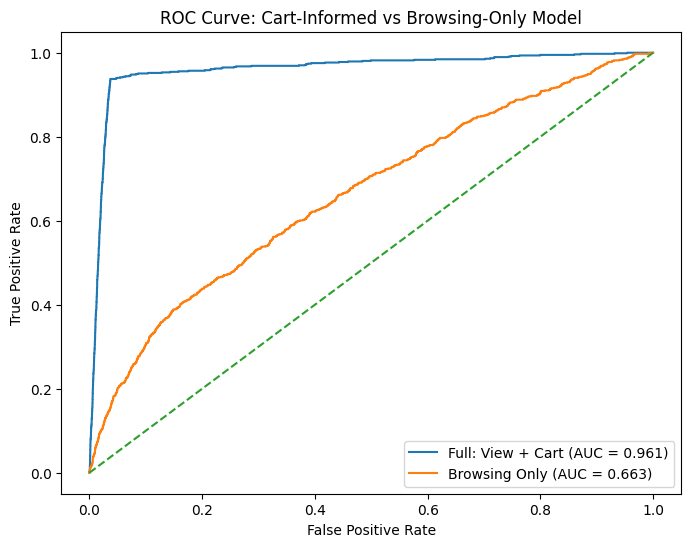

In [ ]:
# -----------------------------
# 6. Plot ROC curves side by side
# -----------------------------

from sklearn.metrics import roc_curve

full_fpr, full_tpr, _ = roc_curve(y_test_compare, full_proba)
browse_fpr, browse_tpr, _ = roc_curve(y_test_compare, browse_proba)

plt.figure(figsize=(8, 6))
plt.plot(
    full_fpr,
    full_tpr,
    label=f"Full: View + Cart (AUC = {full_auc:.3f})"
)
plt.plot(
    browse_fpr,
    browse_tpr,
    label=f"Browsing Only (AUC = {browse_auc:.3f})"
)
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve: Cart-Informed vs Browsing-Only Model")
plt.legend()
plt.show()


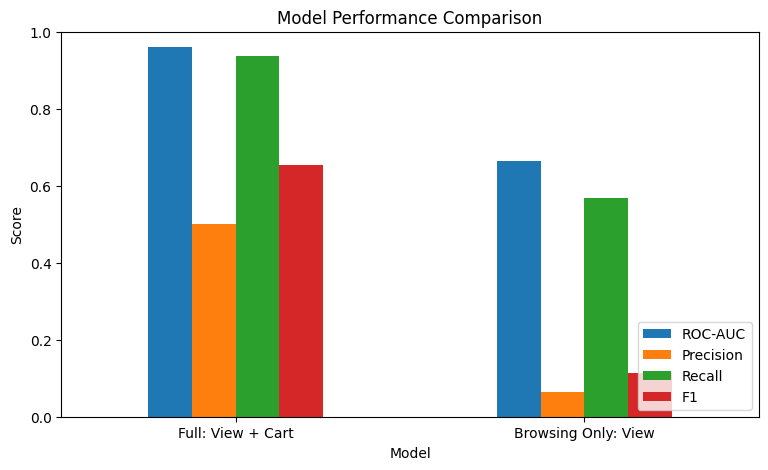

In [ ]:
# -----------------------------
# 7. Compare key metrics visually
# -----------------------------

comparison[["ROC-AUC", "Precision", "Recall", "F1"]].plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xlabel("Model")
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.legend(loc="lower right")
plt.show()


### Final Model Comparison Takeaway

The model comparison shows a large performance gap between browsing-only behavior and browsing + cart behavior.

- **Browsing-only ROC-AUC:** 0.663
- **Full view + cart ROC-AUC:** 0.961
- **ROC-AUC gain from cart-stage information:** +0.298

The browsing-only model provides some predictive signal, but its discrimination is much weaker. Once cart-stage behavior is included, the model becomes substantially better at separating purchasing from non-purchasing sessions.

From a business perspective, the result suggests two different use cases:

1. **Browsing-only scoring** can be used earlier in the customer journey, when the available signal is weaker but there may still be time to influence behavior.
2. **Cart-informed scoring** is better suited to identifying high-intent sessions later in the funnel for actions such as cart reminders, remarketing, or personalized checkout messaging.

